In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
print(df.describe())

Dataset shape: (768, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Summary statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  1

In [ ]:
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features].copy()

print("Selected features:")
print(X.columns.tolist())

Selected features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [ ]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in zero_columns:
    print(col, ":", (X[col] == 0).sum())

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


In [ ]:
for col in zero_columns:
    X[col] = X[col].replace(0, np.nan)

for col in zero_columns:
    X[col] = X[col].fillna(X[col].median())

print("Missing values after preprocessing:")
print(X.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed successfully.")
print("Scaled data shape:", X_scaled.shape)

Standardization completed successfully.
Scaled data shape: (768, 8)


In [ ]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

print("Inertia values:")
for k, value in zip(K, inertia):
    print(f"k = {k}: {value:.2f}")

Inertia values:
k = 2: 4975.02
k = 3: 4335.74
k = 4: 3912.70
k = 5: 3678.67
k = 6: 3474.50
k = 7: 3307.31
k = 8: 3145.46
k = 9: 2995.16
k = 10: 2892.03


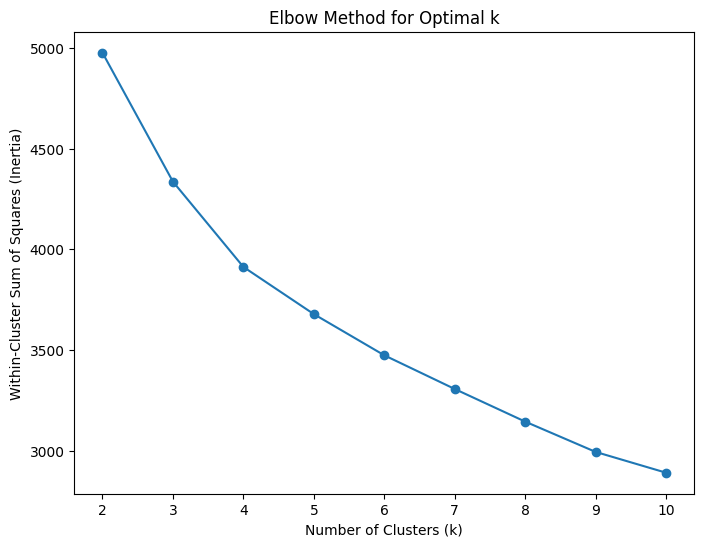

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Optimal k")

plt.xticks(K)
plt.show()

In [ ]:
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("K-Means clustering completed.")
print("\nCluster counts:")
print(df["Cluster"].value_counts().sort_index())

K-Means clustering completed.

Cluster counts:
Cluster
0    248
1    335
2    185
Name: count, dtype: int64


In [ ]:
silhouette = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.19500407738247363


In [ ]:
silhouette_scores = []

for k in range(2, 11):
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans_temp.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette Scores:")
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}: {score:.4f}")

Silhouette Scores:
k = 2: 0.1963
k = 3: 0.1950
k = 4: 0.1898
k = 5: 0.1775
k = 6: 0.1682
k = 7: 0.1226
k = 8: 0.1463
k = 9: 0.1466
k = 10: 0.1448


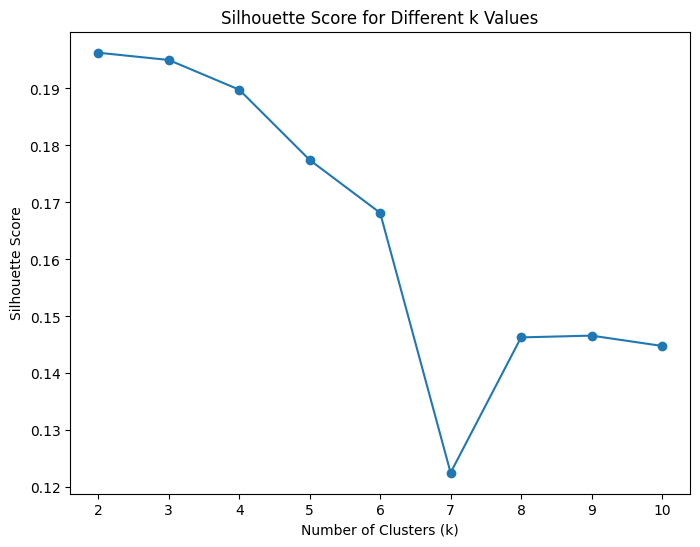

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k Values")

plt.xticks(range(2, 11))
plt.show()

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Reduced number of components:", X_pca.shape[1])

Original number of features: 8
Reduced number of components: 2


In [ ]:
explained_variance = pca.explained_variance_ratio_

print("Explained variance by PC1:", explained_variance[0])
print("Explained variance by PC2:", explained_variance[1])

print("Total explained variance:", explained_variance.sum())

Explained variance by PC1: 0.28537315852858125
Explained variance by PC2: 0.18694721557894944
Total explained variance: 0.4723203741075307


In [ ]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,1.449481,0.659769,0
1,-1.498835,-0.076049,1
2,0.423246,0.761327,0
3,-2.152468,-0.166717,1
4,0.697836,-3.548952,2


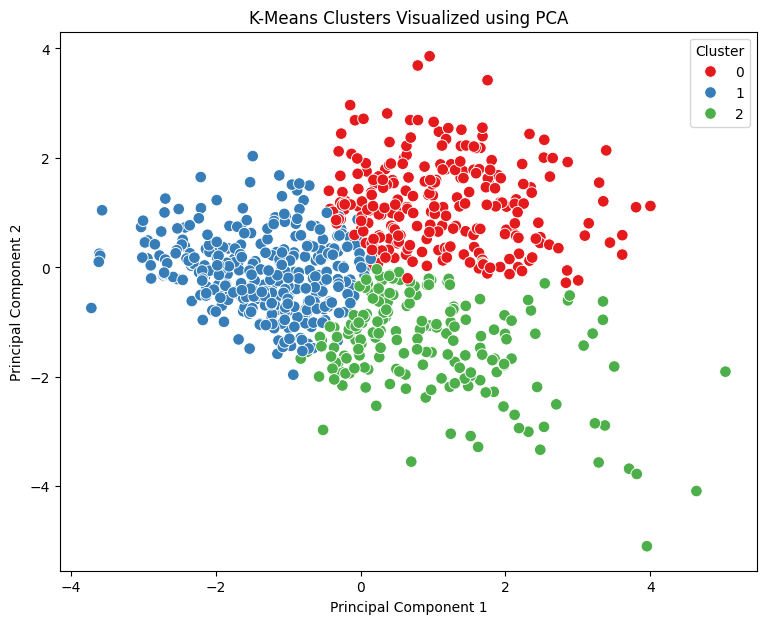

In [ ]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=70
)

plt.title("K-Means Clusters Visualized using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
cluster_outcome = pd.crosstab(
    df["Cluster"],
    df["Outcome"]
)

cluster_outcome.columns = [
    "Non-Diabetic (0)",
    "Diabetic (1)"
]

print(cluster_outcome)

         Non-Diabetic (0)  Diabetic (1)
Cluster                                
0                     120           128
1                     291            44
2                      89            96


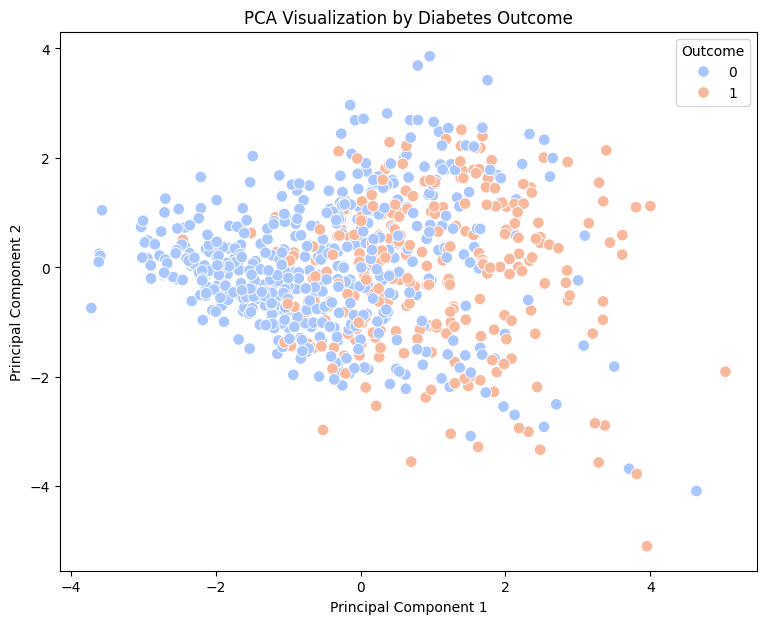

In [ ]:
pca_outcome = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_outcome["Outcome"] = df["Outcome"].values

plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_outcome,
    x="PC1",
    y="PC2",
    hue="Outcome",
    palette="coolwarm",
    s=70
)

plt.title("PCA Visualization by Diabetes Outcome")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()